## Using Copernicus Marine Toolbox
- **Dataset Info:** `cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D`  
- **Time Range:** 5th September 1997 – 28th September 2025  
- **Processing Level:** Level 3  
- **Sensor:** Harmonized Multisensor  


In [35]:
import os
import rioxarray 
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [36]:
ds = xr.open_mfdataset(r'C:\Users\geogdtsci_312\CDEdirectory\geog-312\Chlorophyll_a_levels_within_Kenya_s_EEZ\data\chl_data_*.nc', combine='by_coords')
ds

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 10322, latitude: 144, longitude: 240)
Coordinates:
  * time       (time) datetime64[ns] 83kB 1997-09-05 1997-09-06 ... 2025-12-31
  * latitude   (latitude) float32 576B -5.979 -5.938 -5.896 ... -0.0625 -0.02084
  * longitude  (longitude) float32 960B 38.02 38.06 38.1 ... 47.9 47.94 47.98
Data variables:
    CHL        (time, latitude, longitude) float32 1GB dask.array<chunksize=(365, 144, 240), meta=np.ndarray>
Attributes:
    title:                     cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D
    Conventions:               CF-1.8, ACDD-1.3
    contact:                   servicedesk.cmems@acri-st.fr
    institution:               ACRI
    source:                    surface observation
    history:                   Created using software developed at ACRI-ST
    comment:                   average
    references:                http://www.globcolour.info GlobColour has been...
    copernicusmarine_version:  2.2.5

In [37]:
ds.CHL

<xarray.DataArray 'CHL' (time: 10322, latitude: 144, longitude: 240)> Size: 1GB
dask.array<concatenate, shape=(10322, 144, 240), dtype=float32, chunksize=(366, 144, 240), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 83kB 1997-09-05 1997-09-06 ... 2025-12-31
  * latitude   (latitude) float32 576B -5.979 -5.938 -5.896 ... -0.0625 -0.02084
  * longitude  (longitude) float32 960B 38.02 38.06 38.1 ... 47.9 47.94 47.98
Attributes:
    valid_min:      0.0
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    units:          milligram m-3
    valid_max:      1000.0
    long_name:      Chlorophyll-a concentration - Mean of the binned pixels

In [38]:
chl = ds['CHL']
chl

<xarray.DataArray 'CHL' (time: 10322, latitude: 144, longitude: 240)> Size: 1GB
dask.array<concatenate, shape=(10322, 144, 240), dtype=float32, chunksize=(366, 144, 240), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 83kB 1997-09-05 1997-09-06 ... 2025-12-31
  * latitude   (latitude) float32 576B -5.979 -5.938 -5.896 ... -0.0625 -0.02084
  * longitude  (longitude) float32 960B 38.02 38.06 38.1 ... 47.9 47.94 47.98
Attributes:
    valid_min:      0.0
    standard_name:  mass_concentration_of_chlorophyll_a_in_sea_water
    units:          milligram m-3
    valid_max:      1000.0
    long_name:      Chlorophyll-a concentration - Mean of the binned pixels

In [39]:
plots_dir = r"C:\Users\geogdtsci_312\CDEdirectory\geog-312\Chlorophyll_a_levels_within_Kenya_s_EEZ\pplots"
os.makedirs(plots_dir, exist_ok=True)


In [40]:
seasonal_dict = {
    'North East Monsoon (DJF)': [12, 1, 2],
    'Long Rains (MAM)': [3, 4, 5],
    'South East Monsoon (JJA)': [6, 7, 8],
    'Short Rains (SON)': [9, 10, 11]
}

In [41]:
def filter_by_szn(dataset:xr.Dataset, seasons_info:dict, season:str):
  filtered_ds = dataset.isel(time=dataset.time.dt.month.isin(seasons_info[season]))
  print(f"data filtered to {season} season")
  return filtered_ds

In [42]:
def composite_season(filtered_data:xr.Dataset, dimension:str):
    seasonal_composite = filtered_data.mean(dim=dimension)
    return seasonal_composite

In [43]:

def get_szn_timeseries(filtered_data:xr.Dataset, dimensions:list):
    daily_average = filtered_data.mean(dimensions)
    yearly_average = daily_average.groupby(daily_average.time.dt.year).mean()
    return yearly_average

In [44]:
def generate_title(season:str):
    title = "Average Yearly Chlorophyll-a Concentration in Kenya EEZ during {0} season (1997-2025)".format(season)
    return title

In [45]:
def generate_plot_path(season: str):
    plot_name = f"{season}_timeseries_plot.png"
    plot_path = os.path.join(plots_dir, plot_name)
    return plot_path


In [46]:
generate_plot_path(season='long rains')

'C:\\Users\\geogdtsci_312\\CDEdirectory\\geog-312\\Chlorophyll_a_levels_within_Kenya_s_EEZ\\pplots\\long rains_timeseries_plot.png'

In [47]:
composites = {}
for season in seasonal_dict.keys():
     composite = ds.pipe(filter_by_szn, seasonal_dict, season).pipe(composite_season, 'time')
     composites[season] = composite
composites

data filtered to North East Monsoon (DJF) season
data filtered to Long Rains (MAM) season
data filtered to South East Monsoon (JJA) season
data filtered to Short Rains (SON) season


{'North East Monsoon (DJF)': <xarray.Dataset> Size: 140kB
 Dimensions:    (latitude: 144, longitude: 240)
 Coordinates:
   * latitude   (latitude) float32 576B -5.979 -5.938 -5.896 ... -0.0625 -0.02084
   * longitude  (longitude) float32 960B 38.02 38.06 38.1 ... 47.9 47.94 47.98
 Data variables:
     CHL        (latitude, longitude) float32 138kB dask.array<chunksize=(144, 240), meta=np.ndarray>,
 'Long Rains (MAM)': <xarray.Dataset> Size: 140kB
 Dimensions:    (latitude: 144, longitude: 240)
 Coordinates:
   * latitude   (latitude) float32 576B -5.979 -5.938 -5.896 ... -0.0625 -0.02084
   * longitude  (longitude) float32 960B 38.02 38.06 38.1 ... 47.9 47.94 47.98
 Data variables:
     CHL        (latitude, longitude) float32 138kB dask.array<chunksize=(144, 240), meta=np.ndarray>,
 'South East Monsoon (JJA)': <xarray.Dataset> Size: 140kB
 Dimensions:    (latitude: 144, longitude: 240)
 Coordinates:
   * latitude   (latitude) float32 576B -5.979 -5.938 -5.896 ... -0.0625 -0.02084
   *

In [48]:
time_series = {}
for season in seasonal_dict.keys():
  yearly_avg = ds.pipe(filter_by_szn, seasons_info=seasonal_dict, season=season).pipe(get_szn_timeseries, dimensions=['latitude', 'longitude'])
  time_series[season] = yearly_avg
time_series

data filtered to North East Monsoon (DJF) season
data filtered to Long Rains (MAM) season
data filtered to South East Monsoon (JJA) season
data filtered to Short Rains (SON) season


{'North East Monsoon (DJF)': <xarray.Dataset> Size: 348B
 Dimensions:  (year: 29)
 Coordinates:
   * year     (year) int64 232B 1997 1998 1999 2000 2001 ... 2022 2023 2024 2025
 Data variables:
     CHL      (year) float32 116B dask.array<chunksize=(1,), meta=np.ndarray>,
 'Long Rains (MAM)': <xarray.Dataset> Size: 336B
 Dimensions:  (year: 28)
 Coordinates:
   * year     (year) int64 224B 1998 1999 2000 2001 2002 ... 2022 2023 2024 2025
 Data variables:
     CHL      (year) float32 112B dask.array<chunksize=(1,), meta=np.ndarray>,
 'South East Monsoon (JJA)': <xarray.Dataset> Size: 336B
 Dimensions:  (year: 28)
 Coordinates:
   * year     (year) int64 224B 1998 1999 2000 2001 2002 ... 2022 2023 2024 2025
 Data variables:
     CHL      (year) float32 112B dask.array<chunksize=(1,), meta=np.ndarray>,
 'Short Rains (SON)': <xarray.Dataset> Size: 348B
 Dimensions:  (year: 29)
 Coordinates:
   * year     (year) int64 232B 1997 1998 1999 2000 2001 ... 2022 2023 2024 2025
 Data variables:
  

In [49]:
def timeseries_plotter(timeseries:xr.Dataset, season=None):

    chl = timeseries['CHL'].values
    years = timeseries['year'].values
    xmin, xmax = years.min(), years.max()
    ymin, ymax = 0, chl.max()

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.plot(years, chl, marker='.', color='green')

    title = generate_title(season=season)
    ax.set_title(title)

    ax.set_xlabel("Year")
    ax.set_ylabel("Chlorophyll Concentration in mg per cubic meter")

    xticks = np.arange(xmin, (xmax + 2), 2)
    xtickla = [f'{xtick}' for xtick in xticks]
    ax.xaxis.set_ticks(xticks)
    ax.xaxis.set_ticklabels(xtickla)

    yticks = np.linspace(ymin, (ymax*1.5), 8)
    ytickla = [f'{ytick: 1.2f}' for ytick in yticks]
    ax.yaxis.set_ticks(yticks)
    ax.yaxis.set_ticklabels(ytickla)

    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(visible=True, which='major', axis='both', color='grey', linestyle='--', linewidth=0.6)


    plot_path = generate_plot_path(season)
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

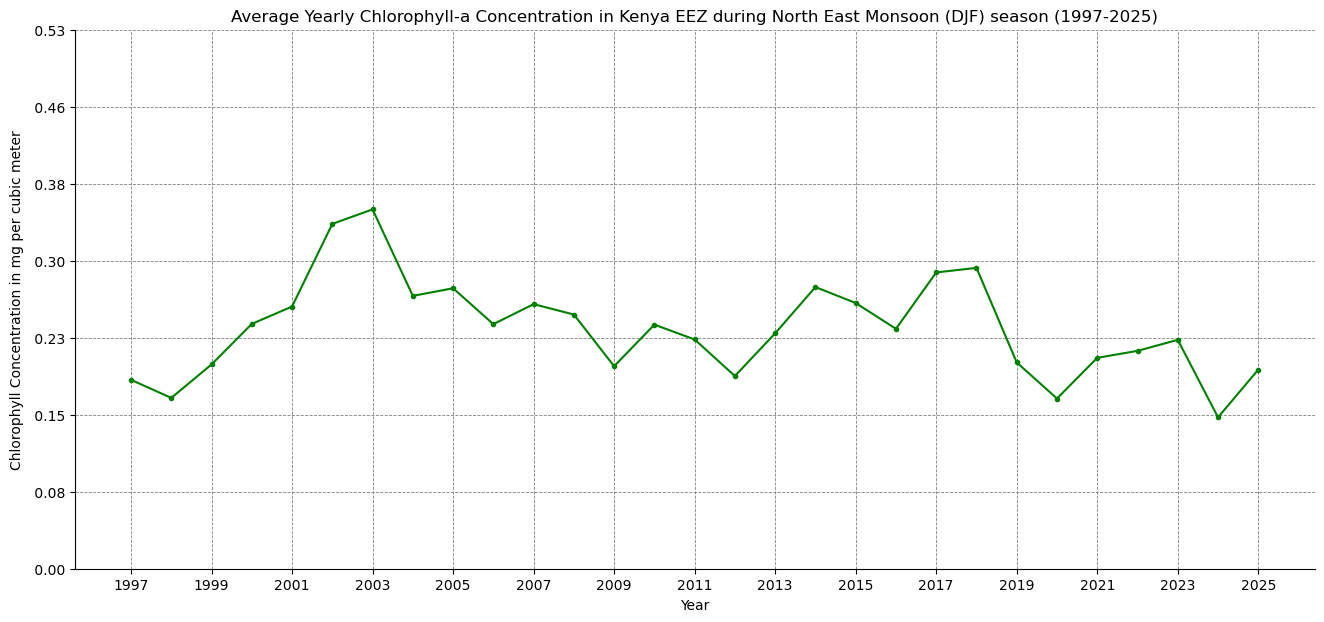

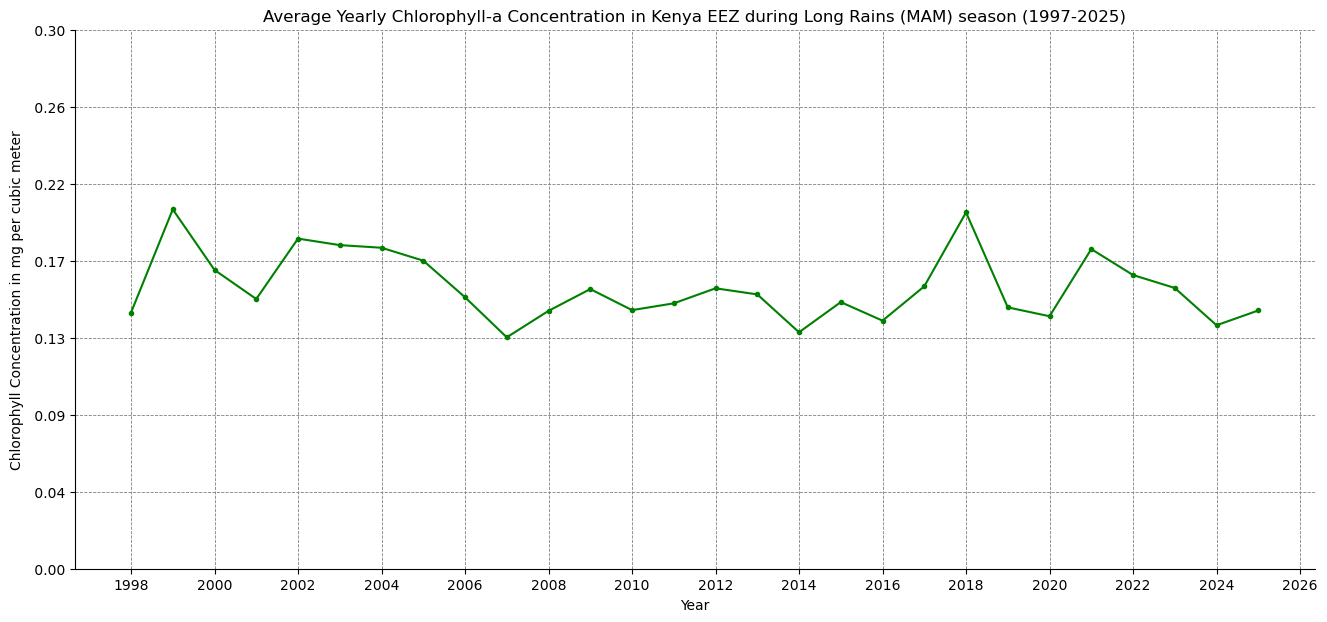

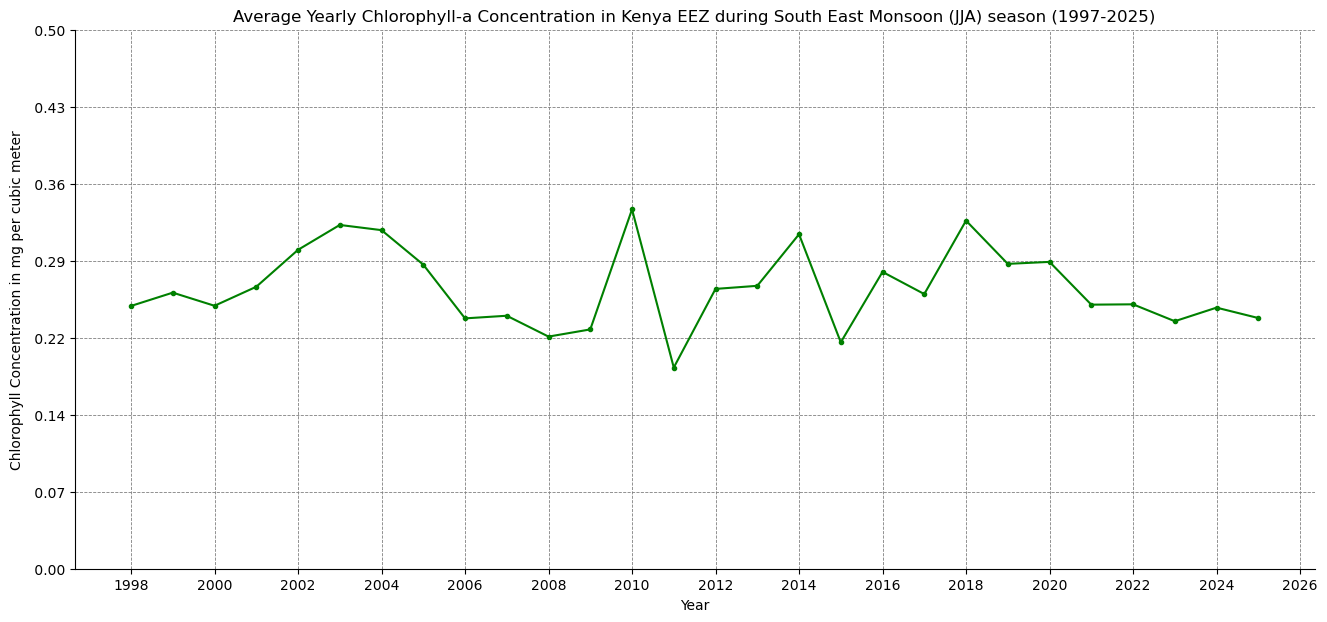

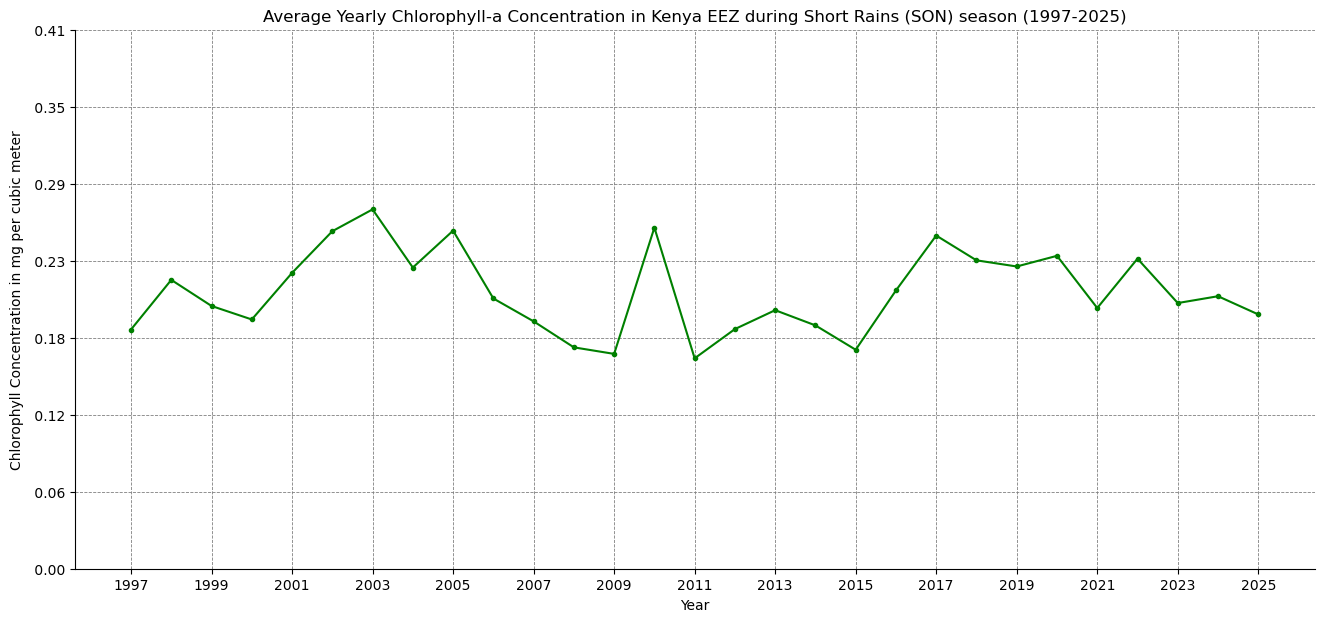

In [50]:
for season, data in time_series.items():
    timeseries_plotter(data, season=season)

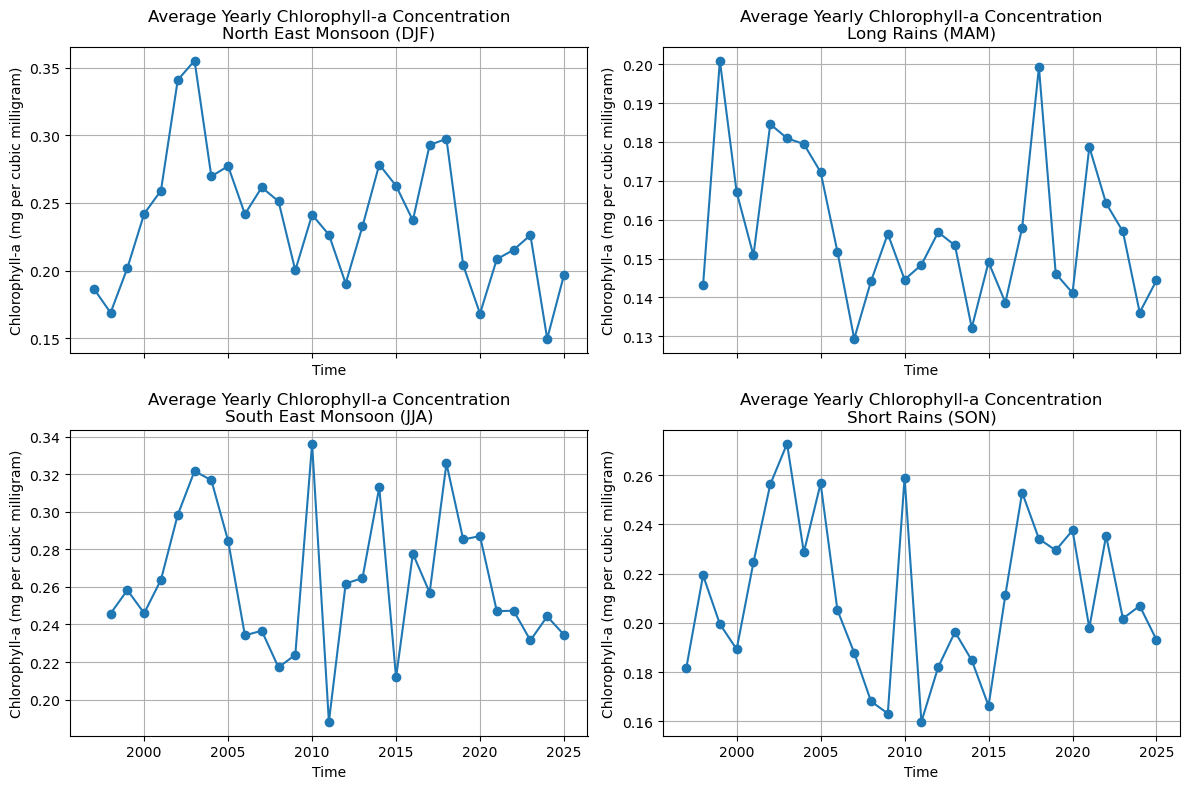

In [51]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, (season, data) in enumerate(time_series.items()):
    data['CHL'].plot(ax=axes[i], marker='o', linestyle='-')
    axes[i].set_title(f'Average Yearly Chlorophyll-a Concentration\n{season}')
    axes[i].set_ylabel('Chlorophyll-a (mg per cubic milligram)')
    axes[i].grid(True)
plt.tight_layout()

plt.savefig(os.path.join(plots_dir, 'seasonal_average_chlorophyll_a.png'),
            dpi=300, bbox_inches="tight")
plt.show()
plt.close()

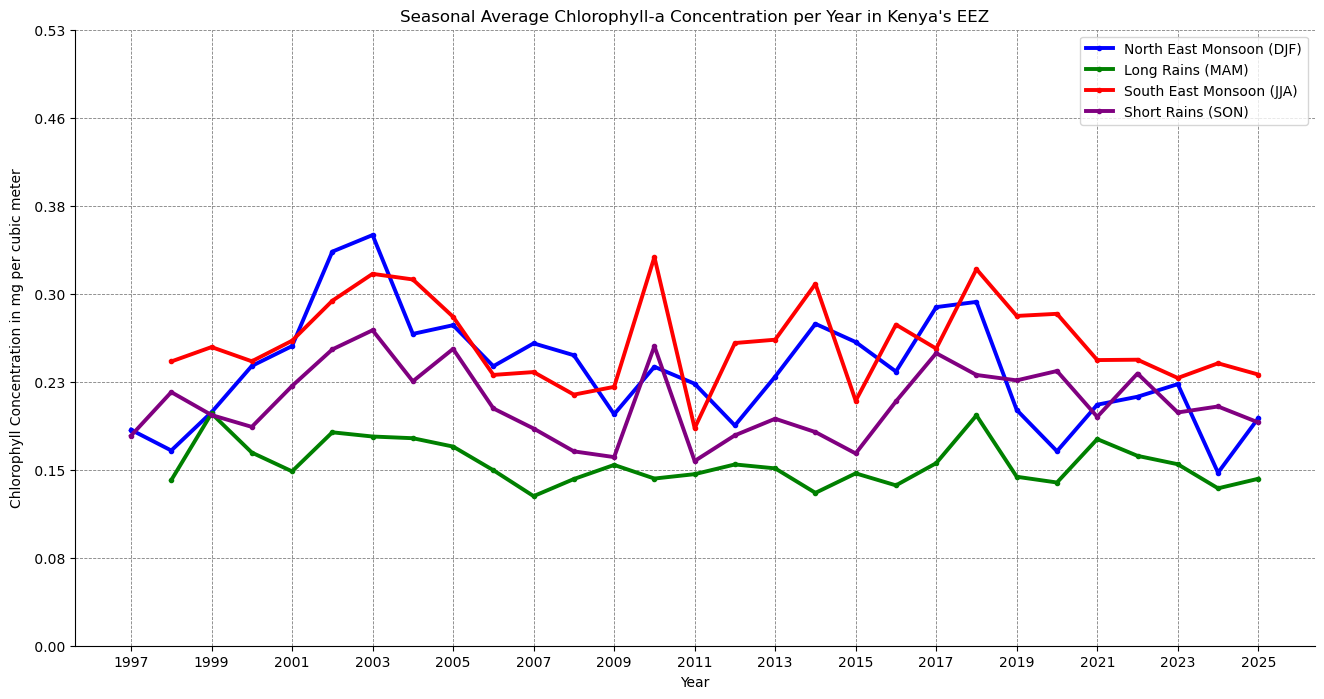

In [52]:
color_dict = {
    'North East Monsoon (DJF)': 'blue',
    'Long Rains (MAM)': 'green',
    'South East Monsoon (JJA)': 'red',
    'Short Rains (SON)': 'purple'
}

all_years = []
all_chl = []
for szn, ts in time_series.items():
    ts = ts.compute()
    all_years.extend(ts['year'].values)
    all_chl.extend(ts['CHL'].values)

xmin, xmax = min(all_years), max(all_years)
ymin, ymax = 0, max(all_chl)

fig, ax = plt.subplots(figsize=(16, 8))
for szn, ts in time_series.items():
    ts = ts.compute()
    chl = ts['CHL'].values
    years = ts['year'].values

    ax.plot(years, chl, marker='.', color=color_dict[szn], linewidth=2.8, label=szn)

ax.set_title("Seasonal Average Chlorophyll-a Concentration per Year in Kenya's EEZ")
ax.set_xlabel("Year")
ax.set_ylabel("Chlorophyll Concentration in mg per cubic meter")

xticks = np.arange(xmin, (xmax + 2), 2)
xtickla = [f'{xtick}' for xtick in xticks]
ax.xaxis.set_ticks(xticks)
ax.xaxis.set_ticklabels(xtickla)

yticks = np.linspace(ymin, (ymax*1.5), 8)
ytickla = [f'{ytick: 1.2f}' for ytick in yticks]
ax.yaxis.set_ticks(yticks)
ax.yaxis.set_ticklabels(ytickla)

ax.spines[['top', 'right']].set_visible(False)
ax.grid(visible=True, which='major', axis='both', color='grey', linestyle='--', linewidth=0.6)
ax.legend()

plt.savefig(os.path.join(plots_dir, 'seasonal_average_chlorophyll_a_concentration.png'),
             dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [53]:
def write_raster(composite:xr.Dataset, parent_folder:str, CRS:str, season:str):
    os.chdir(parent_folder)
    parent_folder = os.getcwd()
    composite = composite.rio.write_crs(CRS)
    raster_name = "{0}\\{1}_composite.tif".format(parent_folder, season)
    composite.rio.to_raster(raster_name)
    print(composite.rio.crs)
    print(raster_name)

rasters_path = os.path.join(os.getcwd(), "Plots", "rasters")
os.makedirs(rasters_path, exist_ok=True)

for season, composite in composites.items():
    write_raster(composite=composite, parent_folder=rasters_path, CRS='EPSG:4326', season=season)

EPSG:4326
c:\Users\geogdtsci_312\CDEdirectory\geog-312\Chlorophyll_a_levels_within_Kenya_s_EEZ\Code\Plots\rasters\Plots\rasters\North East Monsoon (DJF)_composite.tif
EPSG:4326
c:\Users\geogdtsci_312\CDEdirectory\geog-312\Chlorophyll_a_levels_within_Kenya_s_EEZ\Code\Plots\rasters\Plots\rasters\Long Rains (MAM)_composite.tif
EPSG:4326
c:\Users\geogdtsci_312\CDEdirectory\geog-312\Chlorophyll_a_levels_within_Kenya_s_EEZ\Code\Plots\rasters\Plots\rasters\South East Monsoon (JJA)_composite.tif
EPSG:4326
c:\Users\geogdtsci_312\CDEdirectory\geog-312\Chlorophyll_a_levels_within_Kenya_s_EEZ\Code\Plots\rasters\Plots\rasters\Short Rains (SON)_composite.tif
